In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. Load Dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

In [4]:
# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# 3. Xây cây đầy đủ
tree = DecisionTreeRegressor(
    criterion="squared_error",
    random_state=42
)
tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [9]:
# 4. Sinh danh sách alpha
path = tree.cost_complexity_pruning_path(
    X_train,
    y_train
)
print(path)

{'ccp_alphas': array([0.00000000e+00, 1.41643059e-03, 1.41643059e-03, 1.41643059e-03,
       1.41643059e-03, 1.41643059e-03, 1.41643059e-03, 1.41643059e-03,
       1.41643059e-03, 1.41643059e-03, 1.41643059e-03, 1.41643059e-03,
       1.41643059e-03, 1.41643059e-03, 1.41643059e-03, 1.41643059e-03,
       1.88857413e-03, 4.24929178e-03, 4.24929178e-03, 5.66572238e-03,
       5.66572238e-03, 5.66572238e-03, 5.66572238e-03, 5.66572238e-03,
       5.66572238e-03, 5.66572238e-03, 5.66572238e-03, 5.66572238e-03,
       5.66572238e-03, 5.66572238e-03, 7.55429651e-03, 1.14258735e-02,
       1.18035883e-02, 1.27478754e-02, 1.27478754e-02, 1.27478754e-02,
       1.27478754e-02, 1.27478754e-02, 1.27478754e-02, 1.51085930e-02,
       1.91218130e-02, 2.26628895e-02, 2.26628895e-02, 2.26628895e-02,
       2.26628895e-02, 2.26628895e-02, 2.26628895e-02, 2.26628895e-02,
       2.26628895e-02, 2.26628895e-02, 2.26628895e-02, 2.26628895e-02,
       2.26628895e-02, 2.31350330e-02, 3.05949008e-02, 3.54107

In [10]:
# Bỏ alpha cuối (cây chỉ còn nút gốc)
ccp_alphas = path.ccp_alphas[:-1]

print("Candidate alphas:")
print(ccp_alphas)

Candidate alphas:
[0.00000000e+00 1.41643059e-03 1.41643059e-03 1.41643059e-03
 1.41643059e-03 1.41643059e-03 1.41643059e-03 1.41643059e-03
 1.41643059e-03 1.41643059e-03 1.41643059e-03 1.41643059e-03
 1.41643059e-03 1.41643059e-03 1.41643059e-03 1.41643059e-03
 1.88857413e-03 4.24929178e-03 4.24929178e-03 5.66572238e-03
 5.66572238e-03 5.66572238e-03 5.66572238e-03 5.66572238e-03
 5.66572238e-03 5.66572238e-03 5.66572238e-03 5.66572238e-03
 5.66572238e-03 5.66572238e-03 7.55429651e-03 1.14258735e-02
 1.18035883e-02 1.27478754e-02 1.27478754e-02 1.27478754e-02
 1.27478754e-02 1.27478754e-02 1.27478754e-02 1.51085930e-02
 1.91218130e-02 2.26628895e-02 2.26628895e-02 2.26628895e-02
 2.26628895e-02 2.26628895e-02 2.26628895e-02 2.26628895e-02
 2.26628895e-02 2.26628895e-02 2.26628895e-02 2.26628895e-02
 2.26628895e-02 2.31350330e-02 3.05949008e-02 3.54107649e-02
 3.54107649e-02 3.54107649e-02 3.54107649e-02 3.54107649e-02
 3.54107649e-02 3.54107649e-02 3.82436261e-02 4.72143532e-02
 5.099

In [11]:
# 5. Cross Validation
alpha_scores = []

for alpha in ccp_alphas:

    reg = DecisionTreeRegressor(
        criterion="squared_error",
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        reg,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    # đổi dấu vì sklearn trả về -MSE
    alpha_scores.append(-scores.mean())

In [12]:
alpha_scores

[np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6450.143983903421),
 np.float64(6449.362505030181),
 np.float64(6449.387544153813),
 np.float64(6449.387544153813),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6449.673982785603),
 np.float64(6451.529274536105),
 np.floa

In [13]:
# 6. Chọn alpha tốt nhất
best_alpha = ccp_alphas[np.argmin(alpha_scores)]

print("\nBest alpha:", best_alpha)
print("Best CV MSE:", min(alpha_scores))


Best alpha: 201.6003887727345
Best CV MSE: 4032.304108544258


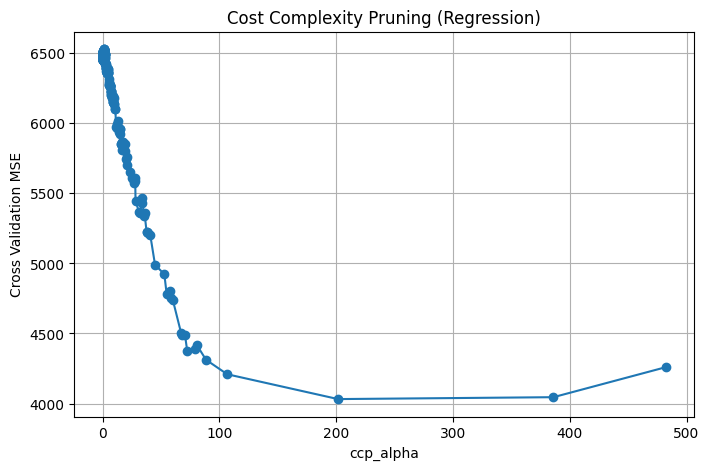

In [14]:
# 7. Vẽ đồ thị
plt.figure(figsize=(8,5))

plt.plot(
    ccp_alphas,
    alpha_scores,
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Cross Validation MSE")
plt.title("Cost Complexity Pruning (Regression)")
plt.grid(True)

plt.show()


In [15]:
# 8. Train mô hình cuối cùng
best_tree = DecisionTreeRegressor(
    criterion="squared_error",
    ccp_alpha=best_alpha,
    random_state=42
)

best_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(201.6003887727345), random_state=42)

In [16]:
# 9. Test
y_pred = best_tree.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========== Test ==========")
print("Test MSE :", mse)
print("Test RMSE:", np.sqrt(mse))
print("Test R²  :", r2)


========== Test ==========
Test MSE : 3735.4996177389003
Test RMSE: 61.1187337707425
Test R²  : 0.2949428791304852
